# Mind Over Motor
by Fiona Stern and Beckett O'Reilly

GitHub Link: https://github.com/bubbyooo/mind-over-motor

In [5]:
import sys
sys.path.append('src')

In [6]:
import dataset
import epocher
import evaluation
import features
import loader
import logistic_regression_model
import model_1d_cnn
import plotEEG
import cnn_data_prep


## Abstract
Our project will address the disconnect between our current understanding of brain signals and their relationship to bodily movement, particularly in brain-computer interfaces to aid those with movement-limiting injuries (e.g., stroke, paralysis) in being able to once again use their own muscles. We aim to classify the target limb movement based on brain activity data collected through EEG. After preparing the raw data, we first engineered the EEG data into features that we used to perform logistic regression to classify the target movements.  Then, we implemented a 1-dimensional convolutional neural network to attempt the same task.  We used graphs of loss, accuracy measures, and confusion matrices to determine our success.  We found the convolutional neural network to be the most successful, with an accuracy of around 53%, which is substantially higher than the base rate accuracy of 33%, and comparable to some extant models.


## Introduction
In our project, we aimed to address the issue of classifying intended motor movement of stroke patients based on their corresponding electroencephalogram (EEG).  Successfully classifying motor movements allows for the creation of technology that can help stroke patients to relearn how to move paralyzed or weakened body parts. This classification task has been attemped previously, although primarily using healthy subjects as opposed to those who have undergone a stroke.  For instance, Cherifi et. al. achieved 97.5% classification accuracy of left vs. right hand using the machine learning algorithm Support Vector Machine (SVP) with Common Spatial Patterns (CSP) algorithm for feature extraction.  For classification models tested on data from stroke patients, accuracy falls substantially.  Liu et. al. published a paper with right/left-hand classification accuracies varying from 55.57% accuracy to 72.21% accuracy, with their most successful model combining the optimal time window and filter bank (TWFB) with discriminant geodesic filtering followed by minimum distance to the Riemannian mean (DGFMDRM) methods.  More recently, Kaviri and Vinjamuri published an article achieving up to 91.03% accuracy on classification for stroke patients, using a customized Residual Convolutional Neural Network with dipole fitting.

## Values Statement

Our project could potentially be used by biotechnology companies to develop brain computer interface technology.  Likely, this BCI technology would be combined with robotics tools, creating a therapy to aid stroke patients (and others with paralysis) to regain control over paralyzed body parts. 

Our project could impact stroke patients, biotechnology companies, hospitals, physical therapists, and doctors.  If successful, stroke patients experiencing some level of paralysis would benefit from this technology.  We do not expect anyone to be harmed from this technology, if implemented successfully.  However, we imagine that financial costs could exclude individuals from the potential benefits.  From a highly dystopian sense, there is also always the danger in having technology that can "read minds" and deliver this information externally, but we think that is unlikely to be a practical issue.

Personally, we are both highly interested in the functioning of the brain.  I, Fiona, have had relatives impacted by strokes, and it is really awesome to think that we might be able to create technology that could improve the quality of life for stroke patients.  

Based on our reflection, we feel confident that the world would become a healtheier and happier place if the model we implemented leads to the creation of BCI-robotics technology to assist stroke patients.  

## Data
In this project, we used a dataset published in the journal Scientific Data, under the title "An EEG motor imagery dataset for brain computer interface in acute stroke patients."

This data was gathered from 50 acute stroke patients who completed specific motory imagery tasks according to on-screen prompts while their EEG data were recorded.  We found it through the website Nature.com, where it is open to public use.

In the dataset, the moter imagery task was our target, and the EEG data served as our feature.  Depending on the model, we engineered the EEG data to be broken down into a series of features.  

The data that we had direct access to was in the form of 50 EDF files, one for each subject of the study.  Each file contained a little over 5 minutes of EEG data, during which the subjects were alternating between reading instructions, imagining moving their left hand, resting, reading new instructions, imagining moving their right hand, and resting again.  A given EDF file contained data for each of the 33 EEG channels, with 160,000 data points in each channel, representing the electrical activity every 2 milliseconds.  

In order to make this data usable, we looped through the EDF file for each subject.  First, we narrowed this data down to only include the three EEG channels that we deemed most relevant based on our research: Cz, C3, and C4.  We also filtered out very high frequency and very low frequency oscillations in the data, as these were more likely to represent artifacts such as an eye-blink than our actual signal.  

We then batched the data, breaking it up into eight second segments () to represent one full cycle of instructions to motor imagery to rest.  We pulled out the middle four seconds of each epoch, which is time during which the trial was actually taking place.  We also then created our feature tensor which lined up with the relevant motor imagery task.

We then added each trial from each subject into one large dataset containing the relevant EEG data, the relevant motor movement, and the subject ID.  From here, we were able to use the data in our models, and keeping the subject ID attached to the data allowed us to split trials either randomly or by subject.

Ultimately, this process leaves us with a list containing 2000 trials corresponding to motor movements, each of which contains 3 rows, corresponding to each channel, with 2000 columns, corresponding to the electrical impulse at each sampling point.  

Here we use the Data_Epoch class to build our dataset. We will then visualize what the first trial looks like for each channel.  

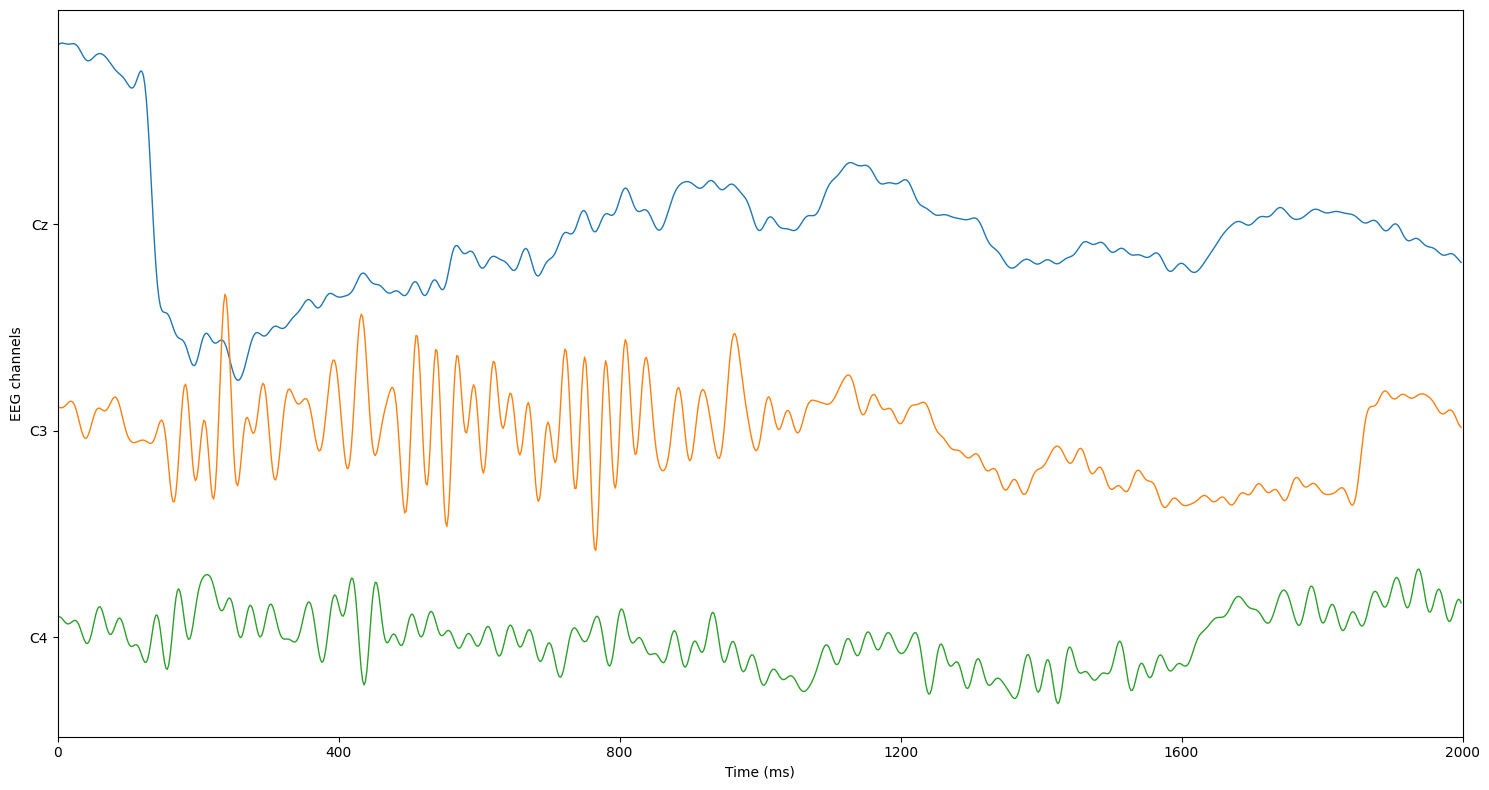

In [7]:
import warnings
warnings.filterwarnings("ignore")  # suppress everything
import mne
mne.set_log_level("ERROR")

epoch = epocher.Data_Epoch()
data = epoch.build_dataset("data")
data_set = dataset.EEGDataset(data)

x,y = data_set[0]

plotEEG.plot(x)



# Our Approach
In order to accurately classify motor imagery in stroke patients, we took a few different approaches.

The features that we used were the raw EEG data obtained from stroke patients as previously mentioned.  Our targets consisted of what the participants were mentally doing.  We had three categories of targets, including imagining moving the left hand, imagining moving the right hand, and resting.   

We did a random split of the data, such that 80% of the trials were including in our training data, and 20% of the trials were included in our validation data.  These trials were randomly taken across all subjects.  While often there is a subject level split for EEG identification tasks in order ensure the generalizability of the data,  we chose to use a random split.  Because the dataset was on a very limited number of stroke patients who had experienced very different types of strokes, we found it very challenging to train on data from some subjects and then apply our model to other subjects. 

We used two different models to approach this problem.  The first was a logistic regression model, which we trained on a selection of engineered features.  We chose this model as we determined that it would give us a good baseline from which to work.  Our problem is a classification problem at its core, and logistic regression provides a nice basis for mulinomial classification. We  noted that several existing models use linear discriminant analysis, which assumes continuous features follows a normal distribution. Since we do not know this to be the case, we though logistic regression would be a reasonable alternative.

We know that there are several aspects of EEG data, such as different types of band power, that are essential to understand to map the electrical signals to brain processes.  As such, for our logistic regression, we used the power of the alpha, beta, mu, and gamma bands as features.  These bands are rhythmic electric imoulses in the brain classified by frequency.  Different types of bands are associated with different states of cognitive processing.  We also calculated the lateral assymetry of each of  the bands across the C3 and C4 electrodes as features.  We determined these features through domaine-level research on the neural processes that correlate to our targets.

Our second model was a customized one-dimensional convolutional neural network.  We determined that this model would be appropriate as 1d-CNNs are highly applicable to time series data, particularly EEGs.  We found that the current best model for our task is a customized version of a cnn, leading us to stick with this model.  We fed in our very lightly pre-processed data to this model.  As mentioned in the data section, we previously had filtered out very high and low frequency oscillations in the data that we deemed to be artifacts irrelevant to our signal.  We fed in the time series data of each of our three most important EEG channels: C3, C4, and Cz, as well as one engineered features, which consisted of the elementalwise multiplication of the C3 and C4 channels.  

This convolutional neural network differed substantially from our work in class in two main ways.  First, we chose to use a one-dimensional cnn as opposed to a two-dimensional cnn because we chose to keep the time-series form of the data rather than converting into spacial data.  Additionally, we used inception blocks that ran several kernel sizes in parallel for each layer of the cnn.  We got this idea from the paper published by Vairi and Vinjamuri.  These inception blocks allowed the model to pick up on EEG features that exist on different time scales.  After much testing, we determined that by having the initial layer contain three kernel sizes, but subsequent layers contain only one kernel, we were able to obtain the best results.

We trained both of our models locally on our computers.  For the CNN, we chose to train our data in batches to reduce overfitting.  We used torch's Adam optimizer along with a learning rate scheduler that reduces the learning rate when the validation loss plateaus.  Although our training loop continues for 1000 epochs, we used a patience metric that stopped training after the validation loss had not improved for 30 consecutive epochs.  The cnn model was trained on an Apple M3 MacBook with 16GB RAM using PyTorch on the CPU.  It tended to take around 10 minutes to train the model.

# info on training logreg model here

We evaluated the models in several ways.  On each model, we used cross-entropy as our loss function in each case.  We graphed the loss of both the training and validation data as the models trained to observe the loss trends and assess which models performed best.  Ultimately, our target metric as we built our models was accuracy.  For our ultimate task of classifying type of motor imagery, accuracy is really all that matters.  We do not believe that there is any greater harm or benefit to guessing one class as opposed to another.  However, we did plot confusion matrices in order to best understand our models biases and tendencies as it assigned classes to our inputs.  

Our test set consisted of 600 trials which is 20% of our data.

Here is an example of our cnn model performing its target task.  We will input the EEG data of six trials from our test set, and it will predict which class the data belongs to.

In [8]:
import pickle

with open("model.pkl", "rb") as f:
    model = pickle.load(f)

_, X, _, y = cnn_data_prep.data_prep(data, .998)

y_preds = model.forward(X).argmax(dim = 1)

label_names = ["left", "right", "rest"]
print("True categories: ")
print([label_names[i] for i in y.tolist()])

print("Predicted categories: ")
print([label_names[i] for i in y_preds.tolist()])

print("Accuracy: ", evaluation.accuracy(model, X, y))

True categories: 
['left', 'rest', 'rest', 'rest', 'left', 'right']
Predicted categories: 
['rest', 'rest', 'rest', 'right', 'right', 'right']
Accuracy:  0.5


# Results - TODO
This is the section in which you describe the main findings or achievements of your model. You can report things like accuracies on train/test data, loss scores, confusion matrices, comparisons between models, etc. Your code in this section should generate the figures and tables that you use to report your results.

Please remember: your results do not speak for themselves. While figures and tables are highly effective forms of communication, your prose is necessary to tell your story

# Concluding discussion - TODO
Your conclusion is the right time to assess:

In what ways did our project work?
Did we meet the goals that we set at the beginning of the project?
How do our results compare to the results of others who have also studied similar problems?
If we had more time, data, or computational resources, what might we do differently in order to improve further?

# Group Contributions Statement

Fiona created the initial pipeline to download, sort, and modify the data. She was responsible for researching other models and approaches to the classification problem. She developed the convolutional neural network model, created accuracy, loss, and confusion matrix plots by which to evaluate it, and spent much time running experiments as she tweaked the model. She created the intial feature preparation for the logistic regression model.  She also readied the repo for the initial submission and (with substantial help from Claude) commented all of the files.  For the blog post, she wrote the frontmatter, abstract, introduction, values statement, data and our approach sections.

Beckett both developed and extensively tested the logistic regression model.  He also modified the deta preparation pipeline and feature extraction, to increase model performance.  He worked to separate out code into individual files, keeping the repository well-organized.

# References

Liu, H., Wei, P., Wang, H., Lv, X., Duan, W., Li, M., Zhao, Y., Wang, Q., Chen, X., Shi, G., Han, B., & Hao, J. (2024). An EEG motor imagery dataset for brain computer interface in acute stroke patients. Scientific Data, 11(1), 131. https://doi.org/10.1038/s41597-023-02787-8

Kaviri, S. M., & Vinjamuri, R. (2024). Integrating Electroencephalography Source Localization and Residual Convolutional Neural Network for Advanced Stroke Rehabilitation. Bioengineering (Basel, Switzerland), 11(10), 967. https://doi.org/10.3390/bioengineering11100967

Morash, V., Bai, O., Furlani, S., Lin, P., & Hallett, M. (2008). Classifying EEG signals preceding right hand, left hand, tongue, and right foot movements and motor imageries. Clinical neurophysiology : official journal of the International Federation of Clinical Neurophysiology, 119(11), 2570–2578. https://doi.org/10.1016/j.clinph.2008.08.013
